In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier


%matplotlib inline

1. Загрузите выборку из файла gbm-data.csv с помощью pandas и преобразуйте ее в массив numpy (параметр values у датафрейма).
В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы, такие как размер, форма и т.д. Разбейте выборку на обучающую и тестовую, используя функцию train_test_split с параметрами test_size = 0.8 и random_state = 241.

In [2]:
df = pd.read_csv("gbm-data.csv")
df.head()

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X = df.loc[:, "D1":"D1776"].values
y = df["Activity"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

2. Обучите GradientBoostingClassifier
с параметрами n_estimators=250, verbose=True, random_state=241 и для каждого значения learning_rate из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:

Преобразуйте полученное предсказание с помощью сигмоидной функции по формуле 1 / (1 + e^{−y_pred}), где y_pred — предсказанное значение.

In [4]:
def sigmoid(y_pred: np.array) -> np.array:
    return 1.0 / (1.0 + np.exp(-y_pred))

Используйте метод staged_decision_function для предсказания качества на обучающей и тестовой выборке на каждой итерации.


In [6]:
def log_loss_results(model, X: np.array, y: np.array):
    return [log_loss(y, sigmoid(y_pred)) for y_pred in model.staged_decision_function(X)]

Вычислите и постройте график значений log-loss (которую можно посчитать с помощью функции sklearn.metrics.log_loss) на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

Learning rate: 1
      Iter       Train Loss   Remaining Time 
         1           1.0190           14.04s
         2           0.9192           14.69s
         3           0.8272           12.86s
         4           0.7834           11.79s
         5           0.7109           11.35s
         6           0.6368           12.05s
         7           0.5797           12.83s
         8           0.5610           12.13s
         9           0.5185           11.80s
        10           0.4984           11.54s
        20           0.1999           10.08s
        30           0.1313            9.11s
        40           0.0790            8.36s
        50           0.0511            7.79s
        60           0.0352            7.25s
        70           0.0245            6.82s
        80           0.0162            6.41s
        90           0.0114            5.99s
       100           0.0077            5.58s
       200           0.0002            1.83s


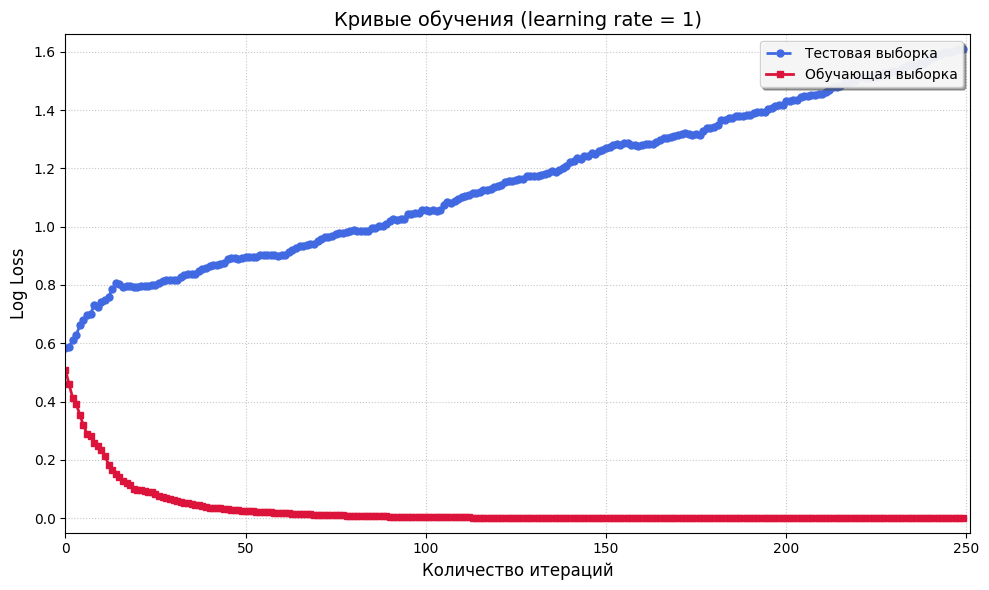

Min loss 0.58 at n_estimators=1

Learning rate: 0.5
      Iter       Train Loss   Remaining Time 
         1           1.1255           10.90s
         2           1.0035           10.52s
         3           0.9386            9.75s
         4           0.8844            8.99s
         5           0.8381            8.85s
         6           0.7995            9.05s
         7           0.7559            9.06s
         8           0.7205            9.03s
         9           0.6958            8.70s
        10           0.6725            8.86s
        20           0.4672            8.15s
        30           0.3179            7.76s
        40           0.2274            7.41s
        50           0.1774            6.96s
        60           0.1394            6.71s
        70           0.1050            6.33s
        80           0.0805            5.96s
        90           0.0650            5.66s
       100           0.0511            5.36s
       200           0.0058            1.83s


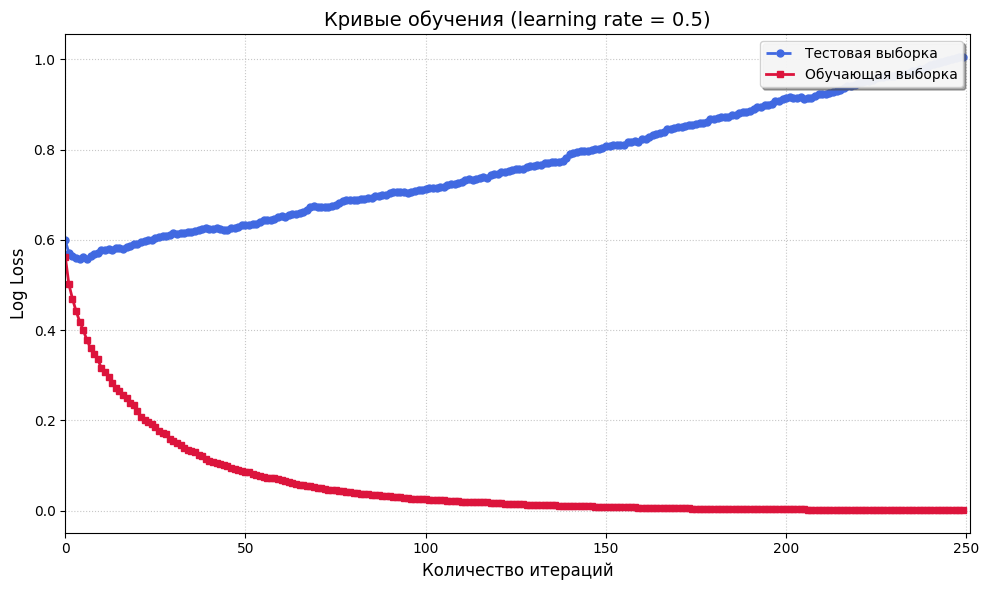

Min loss 0.56 at n_estimators=5

Learning rate: 0.3
      Iter       Train Loss   Remaining Time 
         1           1.2095           16.74s
         2           1.1006           12.08s
         3           1.0240           10.79s
         4           0.9729           10.61s
         5           0.9387            9.66s
         6           0.8948            9.80s
         7           0.8621            9.91s
         8           0.8360            9.90s
         9           0.8171            9.78s
        10           0.7883            9.45s
        20           0.6164            9.13s
        30           0.4933            8.36s
        40           0.4248            7.82s
        50           0.3345            7.69s
        60           0.2760            7.20s
        70           0.2263            6.90s
        80           0.1971            6.59s
        90           0.1693            6.22s
       100           0.1388            5.89s
       200           0.0294            1.99s


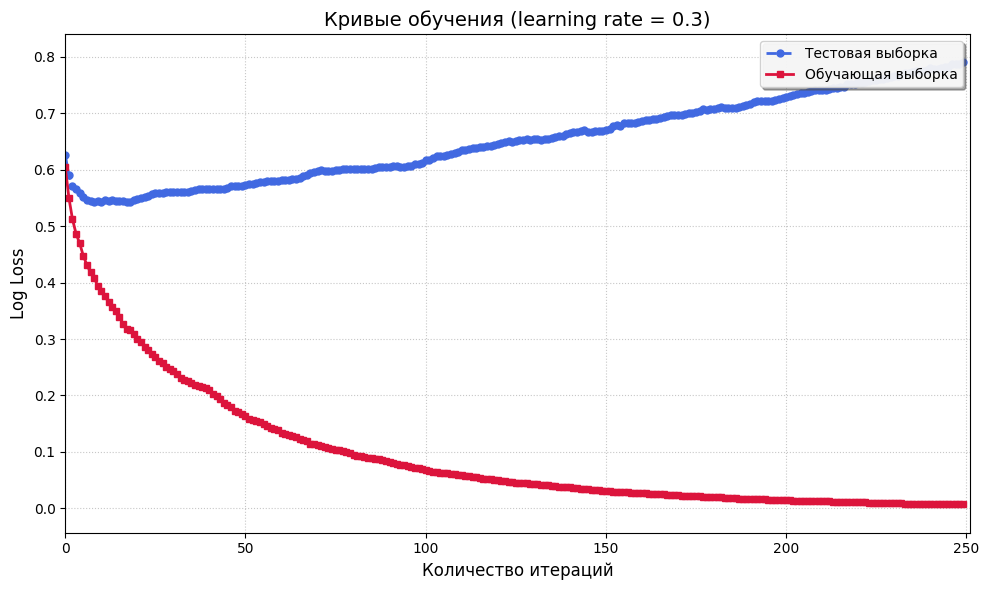

Min loss 0.54 at n_estimators=19

Learning rate: 0.2
      Iter       Train Loss   Remaining Time 
         1           1.2613           11.49s
         2           1.1715           10.32s
         3           1.1009            9.59s
         4           1.0529            9.63s
         5           1.0130            9.56s
         6           0.9740            9.42s
         7           0.9475            9.85s
         8           0.9197            9.57s
         9           0.8979            9.83s
        10           0.8730            9.80s
        20           0.7207            9.39s
        30           0.6055            9.41s
        40           0.5244           12.93s
        50           0.4501           15.85s
        60           0.3908           17.42s
        70           0.3372           17.80s
        80           0.3009           16.90s
        90           0.2603           14.99s
       100           0.2327           13.36s
       200           0.0835            3.41s


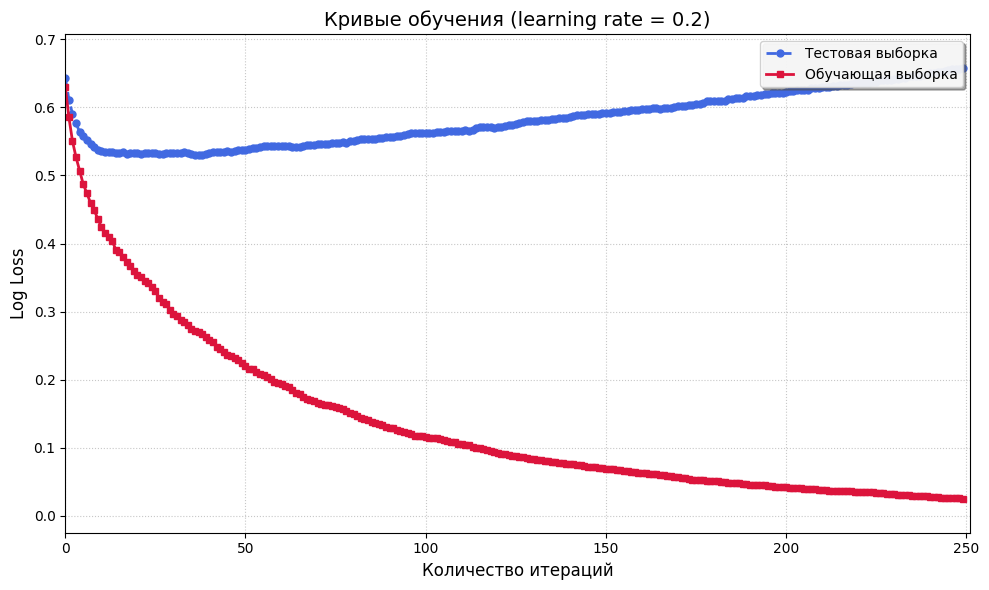

Min loss 0.53 at n_estimators=37

Learning rate: 0.1
      Iter       Train Loss   Remaining Time 
         1           1.3199           12.54s
         2           1.2645           13.00s
         3           1.2170           11.74s
         4           1.1775           11.85s
         5           1.1404           13.71s
         6           1.1106           14.62s
         7           1.0844           13.63s
         8           1.0617           13.53s
         9           1.0411           13.17s
        10           1.0223           13.00s
        20           0.8864           11.60s
        30           0.7844           10.82s
        40           0.7176           10.20s
        50           0.6590            9.57s
        60           0.6120            9.03s
        70           0.5599            8.54s
        80           0.5242            8.11s
        90           0.4829            7.57s
       100           0.4473            7.08s
       200           0.2379            2.33s


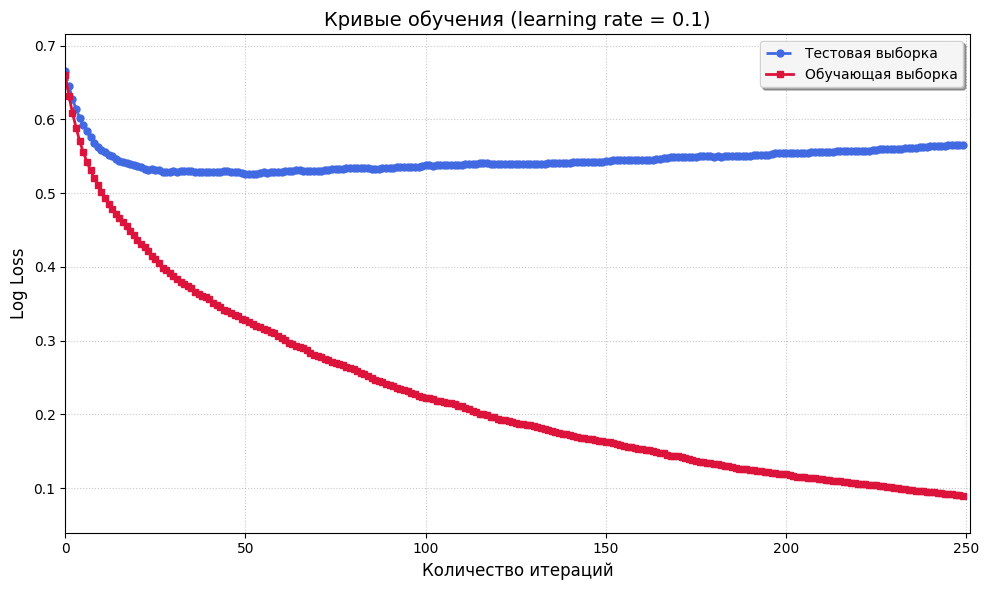

Min loss 0.53 at n_estimators=52



In [10]:
import matplotlib.pyplot as plt
from typing import List

def plot_loss(learning_rate: float, test_loss: List[float], train_loss: List[float]) -> None:
    plt.figure(figsize=(10, 6))

    plt.plot(test_loss, color="royalblue", linestyle="--", linewidth=2, marker="o", markersize=5)
    plt.plot(train_loss, color="crimson", linestyle="-", linewidth=2, marker="s", markersize=5)

    plt.title(f"Кривые обучения (learning rate = {learning_rate})", fontsize=14)
    plt.xlabel("Количество итераций", fontsize=12)
    plt.ylabel("Log Loss", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.7)

    plt.legend(['Тестовая выборка', 'Обучающая выборка'],
               loc="upper right",
               framealpha=0.9,
               shadow=True)

    plt.xlim(0, len(test_loss)+1)
    plt.ylim(min(min(test_loss), min(train_loss))-0.05,
             max(max(test_loss), max(train_loss))+0.05)

    plt.tight_layout()

    plt.show()

min_loss_results = {}
for lr in [1, 0.5, 0.3, 0.2, 0.1]:
    print(f"Learning rate: {lr}")

    model = GradientBoostingClassifier(learning_rate=lr, n_estimators=250, verbose=True, random_state=241)
    model.fit(X_train, y_train)

    train_loss = log_loss_results(model, X_train, y_train)
    test_loss = log_loss_results(model, X_test, y_test)
    plot_loss(lr, test_loss, train_loss)

    min_loss_value = min(test_loss)
    min_loss_index = test_loss.index(min_loss_value) + 1
    min_loss_results[lr] = min_loss_value, min_loss_index

    print(f"Min loss {min_loss_value:.2f} at n_estimators={min_loss_index}\n")

3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)?
В ответе укажите одно из слов overfitting либо underfitting.

In [11]:
print("overfitting")

overfitting


4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при learning_rate = 0.2.

In [13]:
min_loss_value, min_loss_index = min_loss_results[0.2]
print(f"{min_loss_value:.2f} {min_loss_index}")

0.53 37


5. На этих же данных обучите RandomForestClassifier
с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, c random_state=241 и остальными параметрами по умолчанию. Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции predict_proba. В данном случае брать сигмоиду от оценки вероятности класса не нужно)

In [14]:
model = RandomForestClassifier(n_estimators=min_loss_index, random_state=241)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_test)[:, 1]
test_loss = log_loss(y_test, y_pred)

print(f"{test_loss:.2f}")

0.54
